In [1]:
# Install Required Libraries

!pip -q install sentence-transformers
!pip -q install faiss-cpu
!pip -q install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 43.0 MB/s eta 0:00:00


In [2]:
# Import Libraries

import os
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import torch

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
# Download Steam Dataset

import kagglehub

dataset_path = kagglehub.dataset_download(
    "nikdavis/steam-store-games"
)

print(dataset_path)

100%|██████████| 35.2M/35.2M [00:00<00:00, 143MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/nikdavis/steam-store-games/versions/3


In [4]:
# Load CSV Files

steam = pd.read_csv(os.path.join(dataset_path, "steam.csv"))
description = pd.read_csv(os.path.join(dataset_path, "steam_description_data.csv"))
media = pd.read_csv(os.path.join(dataset_path, "steam_media_data.csv"))
support = pd.read_csv(os.path.join(dataset_path, "steam_support_info.csv"))
tags = pd.read_csv(os.path.join(dataset_path, "steamspy_tag_data.csv"))

In [5]:
# Dataset Exploration


print("Steam:", steam.shape)
print("Description:", description.shape)
print("Media:", media.shape)
print("Support:", support.shape)
print("Tags:", tags.shape)

Steam: (27075, 18)
Description: (27334, 4)
Media: (27332, 5)
Support: (27136, 4)
Tags: (29022, 372)


In [6]:
steam.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [7]:
# Data Cleaning

def clean_dataframe(df):
    # Remove duplicate rows
    df = df.drop_duplicates()

    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()]

    return df


steam = clean_dataframe(steam)
description = clean_dataframe(description)
media = clean_dataframe(media)
support = clean_dataframe(support)
tags = clean_dataframe(tags)

print("No more CLEANINGGGGGGGG")

No more CLEANINGGGGGGGG


In [8]:
# Merge All Datasets

final_df = steam.merge(
    description,
    left_on="appid",
    right_on="steam_appid",
    how="left"
)

final_df = final_df.merge(
    tags,
    left_on="appid",
    right_on="appid",
    how="left"
)

final_df = final_df.merge(
    support,
    left_on="appid",
    right_on="steam_appid",
    how="left"
)

print(final_df.shape)

(27075, 397)


In [9]:
# Handle Missing Values


text_columns = [
    "developer",
    "publisher",
    "genres",
    "categories",
    "detailed_description",
    "short_description",
    "tags"
]

for col in text_columns:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna("")

In [10]:
# Text Cleaning Function

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [11]:
# Clean Text Features

columns_to_clean = [
    "name",
    "developer",
    "publisher",
    "genres",
    "categories",
    "steamspy_tags",
    "short_description",
    "detailed_description"
]

for col in columns_to_clean:

    if col in final_df.columns:

        final_df[col] = final_df[col].apply(clean_text)

In [12]:
for col in final_df.columns:
    print(col)

appid
name
release_date
english
developer
publisher
platforms
required_age
categories
genres
steamspy_tags
achievements
positive_ratings
negative_ratings
average_playtime
median_playtime
owners
price
steam_appid_x
detailed_description
about_the_game
short_description
1980s
1990s
2.5d
2d
2d_fighter
360_video
3d
3d_platformer
3d_vision
4_player_local
4x
6dof
atv
abstract
action
action_rpg
action_adventure
addictive
adventure
agriculture
aliens
alternate_history
america
animation_&_modeling
anime
arcade
arena_shooter
artificial_intelligence
assassin
asynchronous_multiplayer
atmospheric
audio_production
bmx
base_building
baseball
based_on_a_novel
basketball
batman
battle_royale
beat_em_up
beautiful
benchmark
bikes
blood
board_game
bowling
building
bullet_hell
bullet_time
crpg
capitalism
card_game
cartoon
cartoony
casual
cats
character_action_game
character_customization
chess
choices_matter
choose_your_own_adventure
cinematic
city_builder
class_based
classic
clicker
co_op
co_op_campaign
co

In [13]:
# Create Combined Text

final_df["combined_text"] = (

    final_df["name"] + " " +

    final_df["developer"] + " " +

    final_df["publisher"] + " " +

    final_df["genres"] + " " +

    final_df["categories"] + " " +

    final_df["steamspy_tags"] + " " +

    final_df["short_description"] + " " +

    final_df["detailed_description"]

)

In [14]:
print(final_df.shape)

final_df[[
    "appid",
    "name",
    "genres",
    "combined_text"
]].head()

(27075, 398)


,appid,name,genres,combined_text
0,10,counter strike,action,counter strike valve valve action multi player...
1,20,team fortress classic,action,team fortress classic valve valve action multi...
2,30,day defeat,action,day defeat valve valve action multi player val...
3,40,deathmatch classic,action,deathmatch classic valve valve action multi pl...
4,50,half life opposing force,action,half life opposing force gearbox software valv...


In [15]:
# Load Sentence Transformer Model

import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device=device
)

Device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
# Generate Semantic Embeddings

texts = final_df["combined_text"].fillna("").tolist()

embeddings = model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/212 [00:00<?, ?it/s]

In [17]:
print(embeddings.shape)

(27075, 384)


In [18]:
import numpy as np

np.save("embeddings.npy", embeddings)

print("Embeddings Saved Successfully")

Embeddings Saved Successfully


In [19]:
query = "zombie apocalypse"

In [20]:
query_embedding = model.encode(
    [query],
    normalize_embeddings=True,
    convert_to_numpy=True
)

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(query_embedding, embeddings)[0]

top_idx = scores.argsort()[-5:][::-1]

final_df.iloc[top_idx][["name", "genres", "steamspy_tags"]]

,name,genres,steamspy_tags
13222,zombie apocalypse,action,action zombie multiplayer
15599,dawn killer zombie,violent gore action adventure,adventure action gore
18538,pixel zombie,action casual indie,action indie casual
18832,zombie crisis last one standing,action adventure indie early access,early access indie action
20104,outbreak zombie,violent action,action violent


In [22]:
!pip -q install faiss-cpu

In [23]:
# Build FAISS Index
import faiss
import numpy as np

# Embeddings must be float32
embeddings = embeddings.astype("float32")

dimension = embeddings.shape[1] # 384

# Cosine Similarity (because embeddings are already normalized)
index = faiss.IndexFlatIP(dimension)

index.add(embeddings) # build the vec db for embs

print("FAISS Index Built Successfully")
print("Total Games Indexed:", index.ntotal)

FAISS Index Built Successfully
Total Games Indexed: 27075


In [24]:
# Semantic Search

def semantic_search(query, top_k=5):


    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")


    scores, indices = index.search(query_embedding, top_k)

    results = final_df.iloc[indices[0]].copy()

    results["Similarity"] = scores[0]

    return results[
        [
            "name",
            "genres",
            "steamspy_tags",
            "Similarity"
        ]
    ]

In [25]:
semantic_search(
    "Open world zombie survival game"
)

,name,genres,steamspy_tags,Similarity
20112,undead factory zombie pandemic,free play strategy,free play strategy rts,0.665303
18832,zombie crisis last one standing,action adventure indie early access,early access indie action,0.659670
22239,zombiehunterz,violent action casual indie simulation,action indie casual,0.659641
20992,zombie desperation,violent gore action casual indie,indie violent action,0.658896
13222,zombie apocalypse,action,action zombie multiplayer,0.658590


In [26]:
# Build TF-IDF Matrix

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1,2),
    sublinear_tf=True
)

tfidf_matrix = tfidf.fit_transform(final_df["combined_text"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (27075, 30000)


In [121]:
# normalize scores
def normalize_scores(scores):
    score_range = scores.max() - scores.min()
    if score_range == 0:
        return np.zeros_like(scores)
    return (scores - scores.min()) / score_range

In [122]:
from sklearn.metrics.pairwise import cosine_similarity

def hybrid_search(query, top_k=5,
                  semantic_weight=0.7,
                  keyword_weight=0.3):

    # Encode query
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype("float32")

    # Semantic search (FAISS)
    semantic_scores, indices = index.search(query_embedding, len(final_df))

    semantic_scores = semantic_scores[0]
    indices = indices[0]

    semantic_scores_aligned = np.zeros(len(final_df))
    semantic_scores_aligned[indices] = semantic_scores

    # Keyword search (TF-IDF)
    query_tfidf = tfidf.transform([query])
    keyword_scores = cosine_similarity(
        query_tfidf,
        tfidf_matrix
    ).flatten()

    # Normalize scores
    semantic_scores_norm = normalize_scores(semantic_scores_aligned)
    keyword_scores_norm = normalize_scores(keyword_scores)

    # Hybrid score
    final_scores = (
        semantic_weight * semantic_scores_norm +
        keyword_weight * keyword_scores_norm
    )

    # Top results
    top_indices = np.argsort(final_scores)[::-1][:top_k]

    results = final_df.iloc[top_indices].copy()

    results["Match Score"] = final_scores[top_indices]
    results["Semantic Score"] = semantic_scores_norm[top_indices]
    results["Keyword Score"] = keyword_scores_norm[top_indices]

    return results[
        [
            "name",
            "genres",
            "steamspy_tags",
            "Match Score",
            "Semantic Score",
            "Keyword Score"
        ]
    ]

In [123]:
hybrid_search(
    "Left for dead"
)

,name,genres,steamspy_tags,Match Score,Semantic Score,Keyword Score
16673,end day,early access,early access violent vr,0.875769,0.871903,0.884791
20,left 4 dead,action,zombie co op fps,0.848219,0.806641,0.945235
21,left 4 dead 2,action,zombie co op fps,0.836642,0.783875,0.959763
11909,space ghost pirate zombie slayer,action indie,action indie,0.778138,0.970723,0.328772
13397,oath star,action indie,action indie bullet hell,0.754063,0.648661,1.000000


In [124]:
queries = [
    "zombie survival game",
    "football game",
    "car racing",
    "strategy war game",
    "open world rpg"
]

for q in queries:
    print("=" * 80)
    print("Query:", q)
    display(hybrid_search(q))

Query: zombie survival game


,name,genres,steamspy_tags,Match Score,Semantic Score,Keyword Score
18619,deadly contact,action casual free play indie,free play action indie,0.928556,0.897938,1.000000
23443,life living,violent gore action adventure indie simulation...,early access simulation action,0.875392,0.908015,0.799270
15131,masked force zombie survival,action indie,action indie zombie,0.840565,0.943543,0.600284
26922,slow bullet vr,action free play indie,free play action indie,0.839241,0.826550,0.868854
6962,survival enough,action adventure rpg,action adventure rpg,0.824080,0.889324,0.671844


Query: football game


,name,genres,steamspy_tags,Match Score,Semantic Score,Keyword Score
6496,world soccer online,action free play indie massively multiplayer s...,free play sport massively multiplayer,0.896828,0.852611,1.000000
22415,footy ball tournament 2018,action indie simulation sport strategy,sport action strategy,0.884396,1.000000,0.614654
14321,table football pro,sport early access,early access sport,0.879654,0.911823,0.804594
23000,90 football star,action casual indie sport early access,early access sport action,0.844584,0.894448,0.728233
11049,behold kickmen,action casual indie sport,sport action indie,0.830419,0.875876,0.724352


Query: car racing


,name,genres,steamspy_tags,Match Score,Semantic Score,Keyword Score
19390,raceland,casual indie racing,indie casual racing,0.926223,0.894604,1.000000
9778,rc racing road 2 0,racing simulation sport,simulation racing sport,0.838455,0.918005,0.652837
20213,street racing,action indie racing simulation sport,racing sport action,0.830784,0.982930,0.475775
20630,ultimate racing 2d,indie racing simulation sport,racing simulation sport,0.829789,0.954580,0.538609
2865,htr slot car simulation,racing,racing simulation,0.826547,0.843504,0.786980


Query: strategy war game


,name,genres,steamspy_tags,Match Score,Semantic Score,Keyword Score
15630,casus belli battle annihilation,strategy,strategy indie turn based,0.908365,0.891688,0.947278
3878,war game,indie strategy,strategy indie rts,0.905461,0.923667,0.862980
5655,front war,indie strategy,strategy indie turn based strategy,0.847117,0.941500,0.626890
20509,last war 2044,violent gore action strategy early access,early access action strategy,0.828800,0.835799,0.812468
13758,kursk battle prochorovka,indie strategy,strategy indie world war ii,0.806635,0.723765,1.000000


Query: open world rpg


,name,genres,steamspy_tags,Match Score,Semantic Score,Keyword Score
18077,fantasy eden,rpg,rpg indie fantasy,0.874757,0.821082,1.000000
9395,star merc,action adventure casual indie rpg,indie casual adventure,0.830662,0.825321,0.843125
16656,badlands roadtrip,action adventure indie rpg,action indie adventure,0.820235,0.785463,0.901371
16153,region ruin,action adventure indie rpg simulation strategy,rpg adventure indie,0.799569,0.810157,0.774863
22443,survive west,gore action adventure indie rpg simulation ear...,early access simulation action,0.794094,0.968642,0.386815


In [125]:
# Extraxt query keywords
def get_query_keywords(query):
    return set(clean_text(query).split())

# Match keyword with game genre / Tag
def get_shared_terms(query_keywords, game_field_text):
    game_words = set(str(game_field_text).split())
    return list(query_keywords & game_words)

In [126]:
# get Semantic Score
def get_semantic_score(query_embedding, game_index):
    game_embedding = embeddings[game_index].reshape(1, -1)
    score = cosine_similarity(query_embedding, game_embedding)[0][0]
    return round(float(score), 3)

In [127]:
# explainability for each recommendation
def explain_recommendation(query, row):
    query_keywords = get_query_keywords(query)

    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    game_index = row.name

    semantic_score = get_semantic_score(query_embedding, game_index)

    shared_genres = get_shared_terms(query_keywords, row["genres"])
    shared_tags = get_shared_terms(query_keywords, row["steamspy_tags"])
    shared_title_words = get_shared_terms(query_keywords, row["name"])

    reason = generate_reason(shared_genres, shared_tags, shared_title_words, semantic_score)

    return {
        "name": row["name"],
        "match_score": round(row["Match Score"], 3),
        "semantic_score": semantic_score,
        "shared_genres": shared_genres,
        "shared_tags": shared_tags,
        "shared_title_words": shared_title_words,
        "reason": reason
    }

In [128]:
def generate_reason(shared_genres, shared_tags, shared_title_words, semantic_score):
    parts = []
    if shared_title_words:
        parts.append(f"title match: {', '.join(shared_title_words)}")
    if shared_genres:
        parts.append(f"genres: {', '.join(shared_genres)}")
    if shared_tags:
        parts.append(f"tags: {', '.join(shared_tags)}")

    if parts:
        matched = " and ".join(parts)
        return f"Matched on {matched} — {semantic_score*100:.1f}% semantic similarity"
    else:
        return f"Matched by meaning alone — {semantic_score*100:.1f}% semantic similarity"

In [129]:
def explain_results(query, results_df):
    return [explain_recommendation(query, row) for _, row in results_df.iterrows()]

In [130]:
# check similarity
query = "Left for dead"

query_embedding = model.encode(
    [query],
    normalize_embeddings=True,
    convert_to_numpy=True
)

score = get_semantic_score(query_embedding, 21)
print(score)

0.312


In [131]:
results = hybrid_search("zombie survival game")
explanations = explain_results("zombie survival game", results)

for exp in explanations:
    print(exp)

{'name': 'deadly contact', 'match_score': 0.929, 'semantic_score': 0.618, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': [], 'reason': 'Matched by meaning alone — 61.8% semantic similarity'}
{'name': 'life living', 'match_score': 0.875, 'semantic_score': 0.626, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': [], 'reason': 'Matched by meaning alone — 62.6% semantic similarity'}
{'name': 'masked force zombie survival', 'match_score': 0.841, 'semantic_score': 0.655, 'shared_genres': [], 'shared_tags': ['zombie'], 'shared_title_words': ['zombie', 'survival'], 'reason': 'Matched on title match: zombie, survival and tags: zombie — 65.5% semantic similarity'}
{'name': 'slow bullet vr', 'match_score': 0.839, 'semantic_score': 0.561, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': [], 'reason': 'Matched by meaning alone — 56.1% semantic similarity'}
{'name': 'survival enough', 'match_score': 0.824, 'semantic_score': 0.611, 'shared_genres': [], 'shared_

In [132]:
results = hybrid_search("Left for dead")
explanations = explain_results("Left for dead", results)

for exp in explanations:
    print(exp)

{'name': 'end day', 'match_score': 0.876, 'semantic_score': 0.358, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': [], 'reason': 'Matched by meaning alone — 35.8% semantic similarity'}
{'name': 'left 4 dead', 'match_score': 0.848, 'semantic_score': 0.324, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': ['left', 'dead'], 'reason': 'Matched on title match: left, dead — 32.4% semantic similarity'}
{'name': 'left 4 dead 2', 'match_score': 0.837, 'semantic_score': 0.312, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': ['left', 'dead'], 'reason': 'Matched on title match: left, dead — 31.2% semantic similarity'}
{'name': 'space ghost pirate zombie slayer', 'match_score': 0.778, 'semantic_score': 0.408, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': [], 'reason': 'Matched by meaning alone — 40.8% semantic similarity'}
{'name': 'oath star', 'match_score': 0.754, 'semantic_score': 0.243, 'shared_genres': [], 'shared_tags': [], 'shared_titl

In [133]:
results = hybrid_search("counter strike")
explanations = explain_results("counter strike", results)

for exp in explanations:
    print(exp)

{'name': 'counter strike source', 'match_score': 0.975, 'semantic_score': 0.509, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': ['counter', 'strike'], 'reason': 'Matched on title match: counter, strike — 50.9% semantic similarity'}
{'name': 'counter strike condition zero', 'match_score': 0.966, 'semantic_score': 0.508, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': ['counter', 'strike'], 'reason': 'Matched on title match: counter, strike — 50.8% semantic similarity'}
{'name': 'counter strike nexon zombie', 'match_score': 0.915, 'semantic_score': 0.531, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': ['counter', 'strike'], 'reason': 'Matched on title match: counter, strike — 53.1% semantic similarity'}
{'name': 'counter strike global offensive', 'match_score': 0.879, 'semantic_score': 0.505, 'shared_genres': [], 'shared_tags': [], 'shared_title_words': ['counter', 'strike'], 'reason': 'Matched on title match: counter, strike — 50.5% semantic s

In [134]:
def explain_results_df(query, results_df):
    explanations = explain_results(query, results_df)
    explain_df = pd.DataFrame(explanations)

    explain_df = explain_df.rename(columns={
        "match_score": "Match Score",
        "semantic_score": "Semantic Similarity Score",
        "shared_genres": "Shared Genres",
        "shared_tags": "Shared Tags",
        "shared_title_words": "Shared Title Words",
        "reason": "Recommendation Reason",
        "name": "Name"
    })

    return explain_df[[
        "Name", "Match Score", "Semantic Similarity Score",
        "Shared Genres", "Shared Tags", "Shared Title Words",
        "Recommendation Reason"
    ]]

In [135]:
demo_query = "zombie survival game"
demo_results = hybrid_search(demo_query)
explain_results_df(demo_query, demo_results)

,Name,Match Score,Semantic Similarity Score,Shared Genres,Shared Tags,Shared Title Words,Recommendation Reason
0,deadly contact,0.929,0.618,[],[],[],Matched by meaning alone — 61.8% semantic simi...
1,life living,0.875,0.626,[],[],[],Matched by meaning alone — 62.6% semantic simi...
2,masked force zombie survival,0.841,0.655,[],[zombie],"[zombie, survival]","Matched on title match: zombie, survival and t..."
3,slow bullet vr,0.839,0.561,[],[],[],Matched by meaning alone — 56.1% semantic simi...
4,survival enough,0.824,0.611,[],[],[survival],Matched on title match: survival — 61.1% seman...


In [136]:
demo_queries = [
    "zombie survival game",
    "Left for dead",
    "counter strike",
]

for demo_query in demo_queries:
    demo_results = hybrid_search(demo_query)
    print("Query:", demo_query)
    display(explain_results_df(demo_query, demo_results))

Query: zombie survival game


,Name,Match Score,Semantic Similarity Score,Shared Genres,Shared Tags,Shared Title Words,Recommendation Reason
0,deadly contact,0.929,0.618,[],[],[],Matched by meaning alone — 61.8% semantic simi...
1,life living,0.875,0.626,[],[],[],Matched by meaning alone — 62.6% semantic simi...
2,masked force zombie survival,0.841,0.655,[],[zombie],"[zombie, survival]","Matched on title match: zombie, survival and t..."
3,slow bullet vr,0.839,0.561,[],[],[],Matched by meaning alone — 56.1% semantic simi...
4,survival enough,0.824,0.611,[],[],[survival],Matched on title match: survival — 61.1% seman...


Query: Left for dead


,Name,Match Score,Semantic Similarity Score,Shared Genres,Shared Tags,Shared Title Words,Recommendation Reason
0,end day,0.876,0.358,[],[],[],Matched by meaning alone — 35.8% semantic simi...
1,left 4 dead,0.848,0.324,[],[],"[left, dead]","Matched on title match: left, dead — 32.4% sem..."
2,left 4 dead 2,0.837,0.312,[],[],"[left, dead]","Matched on title match: left, dead — 31.2% sem..."
3,space ghost pirate zombie slayer,0.778,0.408,[],[],[],Matched by meaning alone — 40.8% semantic simi...
4,oath star,0.754,0.243,[],[],[],Matched by meaning alone — 24.3% semantic simi...


Query: counter strike


,Name,Match Score,Semantic Similarity Score,Shared Genres,Shared Tags,Shared Title Words,Recommendation Reason
0,counter strike source,0.975,0.509,[],[],"[counter, strike]","Matched on title match: counter, strike — 50.9..."
1,counter strike condition zero,0.966,0.508,[],[],"[counter, strike]","Matched on title match: counter, strike — 50.8..."
2,counter strike nexon zombie,0.915,0.531,[],[],"[counter, strike]","Matched on title match: counter, strike — 53.1..."
3,counter strike global offensive,0.879,0.505,[],[],"[counter, strike]","Matched on title match: counter, strike — 50.5..."
4,easy esports,0.840,0.413,[],[],[],Matched by meaning alone — 41.3% semantic simi...


In [137]:
from datetime import datetime
from collections import Counter

SEARCH_HISTORY = []

def log_search(query, top_k=5):
    results = hybrid_search(query, top_k=top_k)
    explain_df = explain_results_df(query, results)

    SEARCH_HISTORY.append({
        "query": query,
        "timestamp": datetime.now(),
        "num_results": len(explain_df),
        "results": explain_df.to_dict("records"),
    })
    return explain_df

In [138]:
def get_search_history():
    if not SEARCH_HISTORY:
        return pd.DataFrame(columns=["Timestamp","Query","Recommended Game","Match Score","Semantic Similarity Score"])
    rows = []
    for entry in SEARCH_HISTORY:
        for res in entry["results"]:
            rows.append({
                "Timestamp": entry["timestamp"],
                "Query": entry["query"],
                "Recommended Game": res["Name"],
                "Match Score": res["Match Score"],
                "Semantic Similarity Score": res["Semantic Similarity Score"],
            })
    return pd.DataFrame(rows)

In [139]:
def get_most_matched_genres(top_n=10):
    genre_counter = Counter()
    for entry in SEARCH_HISTORY:
        for res in entry["results"]:
            for g in (res.get("Shared Genres") or []):
                genre_counter[g] += 1
    return pd.DataFrame(genre_counter.most_common(top_n), columns=["Genre", "Search Count"])

def plot_most_matched_genres(top_n=10):
    genre_df = get_most_matched_genres(top_n)
    if genre_df.empty:
        print("No search history yet.")
        return
    plt.figure(figsize=(8,5))
    plt.barh(genre_df["Genre"], genre_df["Search Count"])
    plt.gca().invert_yaxis()
    plt.xlabel("Search Count")
    plt.title("Most Searched Genres")
    plt.tight_layout()
    plt.show()

In [140]:
def get_most_matched_tags(top_n=10):
    tag_counter = Counter()

    for entry in SEARCH_HISTORY:
        for res in entry["results"]:
            tag_counter.update(res.get("Shared Tags") or [])

    return pd.DataFrame(
        tag_counter.most_common(top_n),
        columns=["Tag", "Match Count"]
    )
def plot_most_matched_tags(top_n=10):
    tag_df = get_most_matched_tags(top_n)

    if tag_df.empty:
        print("No search history yet.")
        return

    plt.figure(figsize=(8, 5))
    plt.barh(tag_df["Tag"], tag_df["Match Count"])
    plt.gca().invert_yaxis()
    plt.xlabel("Match Count")
    plt.title("Most Matched Tags")
    plt.tight_layout()
    plt.show()

In [141]:
def get_search_statistics():
    if not SEARCH_HISTORY:
        return {"total_searches": 0}
    queries = [e["query"] for e in SEARCH_HISTORY]
    counter = Counter(queries)
    most_common_query, count = counter.most_common(1)[0]
    return {
        "total_searches": len(SEARCH_HISTORY),
        "unique_queries": len(set(queries)),
        "avg_results_per_search": round(float(np.mean([e["num_results"] for e in SEARCH_HISTORY])), 2),
        "most_common_query": most_common_query,
        "most_common_query_count": count,
        "avg_query_length_words": round(float(np.mean([len(q.split()) for q in queries])), 2),
    }

In [142]:
def get_recommendation_metrics():
    history_df = get_search_history()
    if history_df.empty:
        return {"total_recommendations": 0}
    top_games = Counter(history_df["Recommended Game"]).most_common(5)
    return {
        "total_recommendations": len(history_df),
        "avg_match_score": round(float(history_df["Match Score"].mean()), 3),
        "avg_semantic_score": round(float(history_df["Semantic Similarity Score"].mean()), 3),
        "min_match_score": round(float(history_df["Match Score"].min()), 3),
        "max_match_score": round(float(history_df["Match Score"].max()), 3),
        "most_recommended_games": top_games,
    }

def plot_match_score_distribution():
    history_df = get_search_history()
    if history_df.empty:
        print("No search history yet.")
        return
    plt.figure(figsize=(8,5))
    plt.hist(history_df["Match Score"], bins=15, edgecolor="black")
    plt.xlabel("Match Score")
    plt.ylabel("Frequency")
    plt.title("Match Score Distribution")
    plt.tight_layout()
    plt.show()

In [143]:
def print_dashboard():
    print("--- Search Statistics ---")
    for k, v in get_search_statistics().items():
        print(f"{k}: {v}")

    print("\n--- Recommendation Metrics ---")
    for k, v in get_recommendation_metrics().items():
        print(f"{k}: {v}")

    print("\n--- Most Matched Genres ---")
    display(get_most_matched_genres())

    print("\n--- Most Matched Tags ---")
    display(get_most_matched_tags())

    print("\n--- Recent Search History ---")
    display(get_search_history().tail(10))

    plot_most_matched_genres()
    plot_most_matched_tags()
    plot_match_score_distribution()

In [144]:
print("Number of searches logged:", len(SEARCH_HISTORY))
print(SEARCH_HISTORY[0] if SEARCH_HISTORY else "EMPTY")

Number of searches logged: 0
EMPTY


In [145]:
test_queries = [
    # Action & Shooter
    "zombie survival game",
    "multiplayer shooter",
    "first person shooter",
    "military war game",
    "sniper action game",

    # RPG & Adventure
    "open world rpg",
    "fantasy magic adventure",
    "medieval role playing",
    "dungeon crawler",
    "story rich adventure",

    # Horror
    "horror survival",
    "psychological horror",
    "co op horror",
    "escape room puzzle",
    "creepy mystery game",

    # Racing & Sports
    "racing simulator",
    "car racing game",
    "football simulator",
    "basketball sports game",
    "driving simulation",

    # Strategy & Simulation
    "real time strategy",
    "city building simulator",
    "base management game",
    "turn based strategy",
    "resource management",

    # Sandbox & Casual
    "sandbox building game",
    "crafting survival",
    "relaxing casual game",
    "farming simulation",
    "space exploration"
]

In [146]:
for query in test_queries:
    hybrid_search(query)

In [147]:
advanced_queries = [
    "anime fighting",
    "pixel art platformer",
    "roguelike dungeon",
    "roguelite action",
    "souls like",
    "metroidvania",
    "parkour game",
    "post apocalyptic",
    "cyberpunk future",
    "space colony",
    "pirate adventure",
    "detective mystery",
    "stealth action",
    "boss rush",
    "magic spells",
    "dragons fantasy",
    "co op survival",
    "crafting exploration",
    "vr horror",
    "online multiplayer"
]

In [148]:
for query in advanced_queries:
    hybrid_search(query)

--- Search Statistics ---
total_searches: 30
unique_queries: 30
avg_results_per_search: 5.0
most_common_query: zombie survival game
most_common_query_count: 1
avg_query_length_words: 2.63

--- Recommendation Metrics ---
total_recommendations: 150
avg_match_score: 0.861
avg_semantic_score: 0.529
min_match_score: 0.746
max_match_score: 1.0
most_recommended_games: [('sniper fodder', 2), ('resident evil 7 biohazard 7 teaser beginning hour', 2), ('street racing', 2), ('deadly contact', 1), ('life living', 1)]

--- Most Matched Genres ---


,Genre,Search Count
0,racing,10
1,simulation,10
2,strategy,9
3,action,5
4,rpg,5
5,adventure,5
6,sport,5
7,casual,5
8,multiplayer,2



--- Most Matched Tags ---


,Tag,Match Count
0,horror,11
1,racing,10
2,simulation,10
3,strategy,9
4,action,5
5,adventure,5
6,casual,5
7,rich,4
8,story,4
9,turn,4



--- Recent Search History ---


,Timestamp,Query,Recommended Game,Match Score,Semantic Similarity Score
140,2026-07-15 18:56:07.925566,farming simulation,farming simulator 2013 titanium edition,0.959,0.638
141,2026-07-15 18:56:07.925566,farming simulation,farming simulator 15,0.935,0.644
142,2026-07-15 18:56:07.925566,farming simulation,agricultural simulator 2013 steam edition,0.926,0.677
143,2026-07-15 18:56:07.925566,farming simulation,farming simulator 17,0.926,0.602
144,2026-07-15 18:56:07.925566,farming simulation,harvest simulator vr,0.905,0.615
145,2026-07-15 18:56:08.063085,space exploration,last horizon,0.932,0.504
146,2026-07-15 18:56:08.063085,space exploration,fairspace,0.927,0.471
147,2026-07-15 18:56:08.063085,space exploration,discovering space 2,0.874,0.457
148,2026-07-15 18:56:08.063085,space exploration,buzz aldrin space program manager,0.866,0.486
149,2026-07-15 18:56:08.063085,space exploration,starsone,0.827,0.460


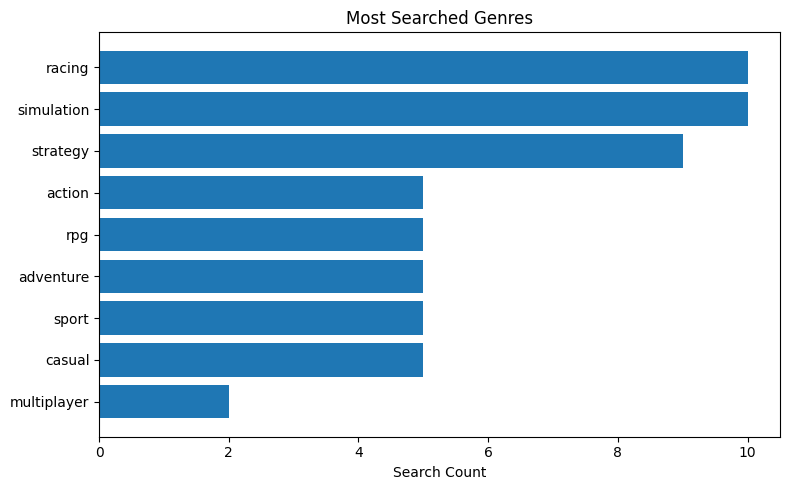

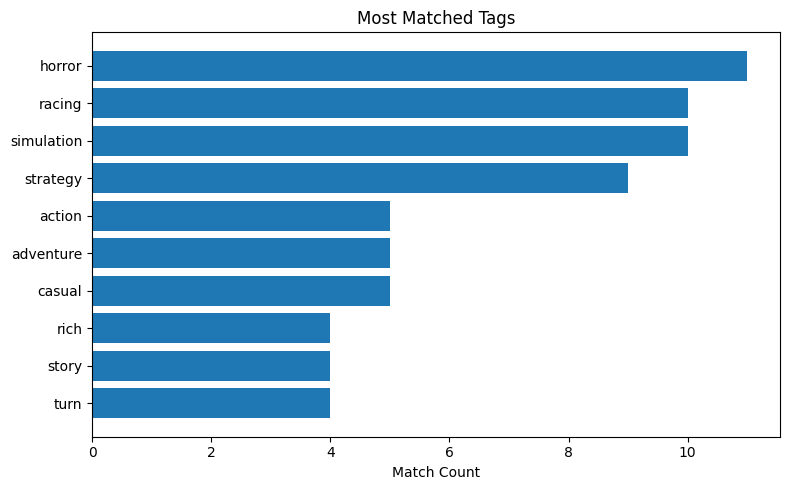

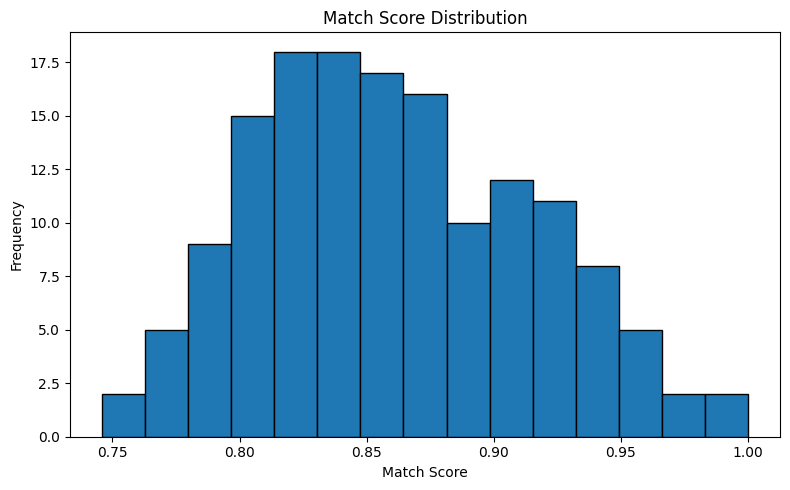

In [149]:
# Optional: start with a clean history
SEARCH_HISTORY.clear()

test_queries = [
    "zombie survival game",
    "multiplayer shooter",
    "first person shooter",
    "military war game",
    "sniper action game",
    "open world rpg",
    "fantasy magic adventure",
    "medieval role playing",
    "dungeon crawler",
    "story rich adventure",
    "horror survival",
    "psychological horror",
    "co op horror",
    "escape room puzzle",
    "creepy mystery game",
    "racing simulator",
    "car racing game",
    "football simulator",
    "basketball sports game",
    "driving simulation",
    "real time strategy",
    "city building simulator",
    "base management game",
    "turn based strategy",
    "resource management",
    "sandbox building game",
    "crafting survival",
    "relaxing casual game",
    "farming simulation",
    "space exploration"
]

for q in test_queries:
    log_search(q)

print_dashboard()

In [151]:
import joblib

joblib.dump(final_df, "final_df.pkl")

['final_df.pkl']

In [152]:
import faiss

faiss.write_index(index, "game_index.faiss")

In [153]:
index = faiss.read_index("game_index.faiss")

In [154]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [155]:
joblib.dump(tfidf_matrix, "tfidf_matrix.pkl")

['tfidf_matrix.pkl']

In [156]:
model.save("sentence_transformer_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [157]:
config = {
    "semantic_weight": 0.7,
    "keyword_weight": 0.3,
    "top_k": 5
}

joblib.dump(config, "config.pkl")

['config.pkl']

In [162]:
import joblib
import faiss

# Save processed dataset
joblib.dump(final_df, "final_df.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save TF-IDF matrix
joblib.dump(tfidf_matrix, "tfidf_matrix.pkl")

# Save FAISS index
faiss.write_index(index, "game_index.faiss")

# Save SentenceTransformer model
model.save("sentence_transformer_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [163]:
import os
import shutil

# Create folder
os.makedirs("Recommendation_System", exist_ok=True)

# Move the saved files into it
shutil.move("final_df.pkl", "Recommendation_System/final_df.pkl")
shutil.move("tfidf_vectorizer.pkl", "Recommendation_System/tfidf_vectorizer.pkl")
shutil.move("tfidf_matrix.pkl", "Recommendation_System/tfidf_matrix.pkl")
shutil.move("game_index.faiss", "Recommendation_System/game_index.faiss")

# Move the model folder
shutil.move("sentence_transformer_model", "Recommendation_System/sentence_transformer_model")

'Recommendation_System/sentence_transformer_model/sentence_transformer_model'

In [164]:
print(os.listdir("Recommendation_System/sentence_transformer_model"))

['config.json', 'model.safetensors', 'tokenizer_config.json', 'sentence_transformer_model', 'README.md', 'config_sentence_transformers.json', 'modules.json', 'sentence_bert_config.json', '2_Normalize', '1_Pooling', 'tokenizer.json']


In [169]:
import shutil

shutil.make_archive("Recommendation_System", "zip", "Recommendation_System")

'/content/Recommendation_System.zip'

In [170]:
from google.colab import files

files.download("Recommendation_System.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>